In [1]:
import torch

print(f"Apakah CUDA (GPU) tersedia? : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"Nama GPU yang digunakan : {torch.cuda.get_device_name(0)}")
    print(f"Total VRAM GPU          : {round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 1)} GB")
else:
    print("GPU tidak terdeteksi, hanya menggunakan CPU.")

Apakah CUDA (GPU) tersedia? : True
Nama GPU yang digunakan : NVIDIA GeForce RTX 3060 Laptop GPU
Total VRAM GPU          : 6.0 GB


# Set Up

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# from ultralytics import YOLO

# gunakan model ringan dulu
# yolo_model = YOLO("yolov8n.pt")

import cv2
import numpy as np
import os
from tqdm import tqdm

from sklearn.model_selection import train_test_split

import torchvision.transforms as T

from torch.utils.data import DataLoader
import torch
import torchvision
from torch.utils.data import Dataset
from PIL import Image

import torch.nn as nn
import timm

from retinaface import RetinaFace



d:\Penyimpanan\Documents\SEMESTER 6\data-lab\env_ai\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Set up Path

In [3]:
import os

BASE_DIR = os.getcwd()

TRAIN_DIR = os.path.join(BASE_DIR, 'dataset', 'train')
TEST_DIR = os.path.join(BASE_DIR, 'dataset', 'test')

print(f'Training data directory: {TRAIN_DIR}')
print(f'Testing data directory: {TEST_DIR}')

Training data directory: d:\Penyimpanan\Documents\SEMESTER 6\data-lab\data-comp\data-analytics-competition-find-it-2026\dataset\train
Testing data directory: d:\Penyimpanan\Documents\SEMESTER 6\data-lab\data-comp\data-analytics-competition-find-it-2026\dataset\test


In [4]:
print(f"Jumlah file train: {len(os.listdir(TRAIN_DIR))}")
print(f"Jumlah file test: {len(os.listdir(TEST_DIR))}")

Jumlah file train: 6
Jumlah file test: 404


# Load Dataset

In [5]:

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_data = datasets.ImageFolder(TRAIN_DIR, transform=transform)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)

print("Classes:", train_data.classes)

Classes: ['fake_mannequin', 'fake_mask', 'fake_printed', 'fake_screen', 'fake_unknown', 'realperson']


fake_mannequin


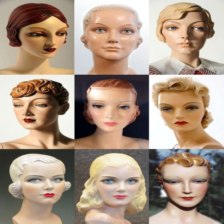

fake_mask


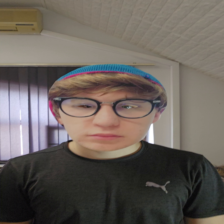

fake_printed


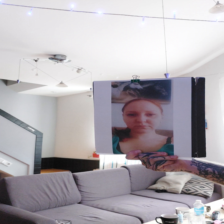

fake_screen


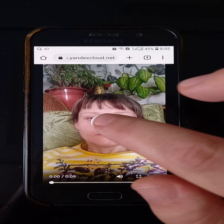

fake_unknown


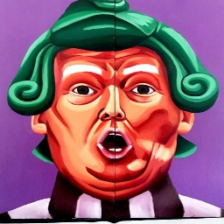

realperson


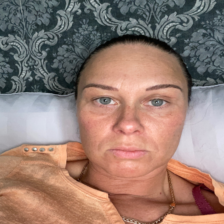

In [6]:
from IPython.display import display
from torchvision.transforms.functional import to_pil_image

num_classes = len(train_data.classes)

# Ambil satu batch
images, labels = next(iter(train_loader))

# Kelompokkan berdasarkan label
unique_labels = {}
for img, label in zip(images, labels):
    label_idx = label.item()
    if label_idx not in unique_labels:
        unique_labels[label_idx] = img
    if len(unique_labels) == num_classes:
        break

# Tampilkan 1 gambar per class (tanpa matplotlib)
for idx in range(num_classes):
    if idx in unique_labels:
        print(train_data.classes[idx])
        display(to_pil_image(unique_labels[idx]))

# Face Cropping (RetinaFace)

In [8]:
import os
import cv2
import numpy as np
from tqdm import tqdm
from retinaface import RetinaFace

# Pastikan BASE_DIR, TRAIN_DIR, dan TEST_DIR sudah terdefinisi seperti di sel Anda sebelumnya
# BASE_DIR = os.getcwd()
# TRAIN_DIR = os.path.join(BASE_DIR, 'dataset', 'train')
# TEST_DIR = os.path.join(BASE_DIR, 'dataset', 'test')

# Definisikan direktori output untuk Multi-Context
OUTPUT_TIGHT_DIR = os.path.join(BASE_DIR, 'dataset_tight_crop') # Margin 0.1
OUTPUT_LOOSE_DIR = os.path.join(BASE_DIR, 'dataset_loose_crop') # Margin 0.4

def process_and_crop(input_dir, output_dir, margin):
    """
    Fungsi untuk mendeteksi, memotong (crop) wajah dengan margin tertentu, 
    dan menyimpannya ke folder baru dengan struktur sub-folder (kelas) yang sama.
    """
    print(f"\\nMemproses dataset dengan margin: {margin}")
    print(f"Menyimpan ke: {output_dir}")
    
    # Periksa apakah ini direktori train (ada sub-folder label) atau test (langsung file)
    is_train_dir = any(os.path.isdir(os.path.join(input_dir, d)) for d in os.listdir(input_dir))
    
    if is_train_dir:
        classes = os.listdir(input_dir)
        for cls in classes:
            cls_in_path = os.path.join(input_dir, cls)
            cls_out_path = os.path.join(output_dir, 'train', cls)
            os.makedirs(cls_out_path, exist_ok=True)
            
            # Loop setiap gambar di dalam kelas
            files = [f for f in os.listdir(cls_in_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            for file_name in tqdm(files, desc=f"Cropping {cls} (Margin {margin})"):
                img_path = os.path.join(cls_in_path, file_name)
                save_path = os.path.join(cls_out_path, file_name)
                
                _detect_and_save(img_path, save_path, margin)
    else:
        # Untuk data TEST (biasanya tidak ada sub-folder kelas)
        test_out_path = os.path.join(output_dir, 'test')
        os.makedirs(test_out_path, exist_ok=True)
        
        files = [f for f in os.listdir(input_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        for file_name in tqdm(files, desc=f"Cropping Test Data (Margin {margin})"):
            img_path = os.path.join(input_dir, file_name)
            save_path = os.path.join(test_out_path, file_name)
            
            _detect_and_save(img_path, save_path, margin)


def _detect_and_save(img_path, save_path, margin):
    """Fungsi internal untuk mendeteksi dan menyimpan 1 gambar tunggal."""
    img = cv2.imread(img_path)
    if img is None:
        return
    
    # RetinaFace butuh format RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Deteksi wajah
    detections = RetinaFace.detect_faces(img_rgb)
    
    if isinstance(detections, dict) and len(detections) > 0:
        # Ambil wajah pertama/utama yang dideteksi
        key = list(detections.keys())[0]
        face = detections[key]['facial_area']
        x1, y1, x2, y2 = face
        
        h, w, _ = img.shape
        
        # Tambahkan margin (Konteks)
        dx = int((x2 - x1) * margin)
        dy = int((y2 - y1) * margin)
        
        x1 = max(0, x1 - dx)
        y1 = max(0, y1 - dy)
        x2 = min(w, x2 + dx)
        y2 = min(h, y2 + dy)
        
        cropped = img[y1:y2, x1:x2]
        cv2.imwrite(save_path, cropped)
    else:
        # FALLBACK: Jika RetinaFace gagal mendeteksi wajah (misal gambar blur atau gelap),
        # Jangan hapus datanya! Simpan gambar aslinya agar loss model tidak terganggu.
        cv2.imwrite(save_path, img)

# Eksekusi Pembuatan Dataset
# 1. Buat Dataset Tight Crop (Untuk di-training dengan CNN / EfficientNet)
process_and_crop(TRAIN_DIR, OUTPUT_TIGHT_DIR, margin=0.1)
process_and_crop(TEST_DIR, OUTPUT_TIGHT_DIR, margin=0.1)

# 2. Buat Dataset Loose Crop (Untuk di-training dengan Transformer / ConvNeXt)
process_and_crop(TRAIN_DIR, OUTPUT_LOOSE_DIR, margin=0.4)
process_and_crop(TEST_DIR, OUTPUT_LOOSE_DIR, margin=0.4)

print("\nBerhasil! Dataset Multi-Context siap digunakan.")

\nMemproses dataset dengan margin: 0.1
Menyimpan ke: d:\Penyimpanan\Documents\SEMESTER 6\data-lab\data-comp\data-analytics-competition-find-it-2026\dataset_tight_crop


Cropping realperson (Margin 0.1): 100%|██████████| 409/409 [32:40<00:00,  4.79s/it]


\nMemproses dataset dengan margin: 0.1
Menyimpan ke: d:\Penyimpanan\Documents\SEMESTER 6\data-lab\data-comp\data-analytics-competition-find-it-2026\dataset_tight_crop


Cropping Test Data (Margin 0.1): 100%|██████████| 404/404 [33:13<00:00,  4.93s/it]


\nMemproses dataset dengan margin: 0.4
Menyimpan ke: d:\Penyimpanan\Documents\SEMESTER 6\data-lab\data-comp\data-analytics-competition-find-it-2026\dataset_loose_crop


Cropping realperson (Margin 0.4): 100%|██████████| 409/409 [32:35<00:00,  4.78s/it]


\nMemproses dataset dengan margin: 0.4
Menyimpan ke: d:\Penyimpanan\Documents\SEMESTER 6\data-lab\data-comp\data-analytics-competition-find-it-2026\dataset_loose_crop


Cropping Test Data (Margin 0.4): 100%|██████████| 404/404 [30:40<00:00,  4.56s/it]


Berhasil! Dataset Multi-Context siap digunakan.


# Persiapan Data

## Stratified 5-fold cross validation + augmentation (tight crop)

In [10]:
import os
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from PIL import Image
from sklearn.model_selection import StratifiedKFold

# ==========================================
# 1. PERSIAPAN DATA (MAPPING PATH KE LABEL)
# ==========================================
# Ganti dengan 'dataset_loose_crop' jika ingin melatih model Transformer
DATA_DIR = os.path.join(os.getcwd(), 'dataset_tight_crop', 'train')

data_list = []
classes = sorted(os.listdir(DATA_DIR))
class_to_idx = {cls_name: idx for idx, cls_name in enumerate(classes)}

# Crawling folder untuk mencatat path dan label
for cls_name in classes:
    cls_dir = os.path.join(DATA_DIR, cls_name)
    for img_name in os.listdir(cls_dir):
        if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            data_list.append({
                'filepath': os.path.join(cls_dir, img_name),
                'label': class_to_idx[cls_name]
            })

df = pd.DataFrame(data_list)
print(f"Total data ditemukan: {len(df)} gambar")
print(f"Mapping Kelas: {class_to_idx}\n")

# ==========================================
# 2. PEMBAGIAN STRATIFIED 5-FOLD
# ==========================================
# Menambahkan kolom 'fold' ke dalam DataFrame
df['fold'] = -1
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(df, df['label'])):
    df.loc[val_idx, 'fold'] = fold_idx

# Cek distribusi kelas di Fold 0 untuk membuktikan Stratified berfungsi
print("Distribusi kelas pada Data Validasi (Fold 0):")
print(df[df['fold'] == 0]['label'].value_counts().sort_index())
print("-" * 50)


# ==========================================
# 3. KELAS DATASET & AUGMENTASI
# ==========================================
class FaceLivenessDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, 'filepath']
        label = self.df.loc[idx, 'label']

        # Buka gambar dan pastikan formatnya RGB
        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, label

# Transformasi
train_tf = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(10),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    # RandomErasing menimpa kotak hitam acak di wajah, memaksa model mencari pola lain
    T.RandomErasing(p=0.2, scale=(0.02, 0.1), ratio=(0.3, 3.3), value=0) 
])

val_tf = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


# ==========================================
# 4. IMPLEMENTASI DATALOADER UNTUK TRAINING
# ==========================================
# Tentukan Fold mana yang ingin dilatih (Biasanya dilooping dari 0 sampai 4)
FOLD_TO_TRAIN = 0  

train_df = df[df['fold'] != FOLD_TO_TRAIN]
val_df = df[df['fold'] == FOLD_TO_TRAIN]

train_dataset = FaceLivenessDataset(train_df, transform=train_tf)
val_dataset = FaceLivenessDataset(val_df, transform=val_tf)

# Gunakan num_workers dan pin_memory untuk transfer data super cepat ke VRAM GPU 6GB
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)

print(f"Siap melatih Fold {FOLD_TO_TRAIN}!")
print(f"Jumlah batch Train Loader : {len(train_loader)} batches")
print(f"Jumlah batch Val Loader   : {len(val_loader)} batches")

Total data ditemukan: 1469 gambar
Mapping Kelas: {'fake_mannequin': 0, 'fake_mask': 1, 'fake_printed': 2, 'fake_screen': 3, 'fake_unknown': 4, 'realperson': 5}

Distribusi kelas pada Data Validasi (Fold 0):
label
0    42
1    51
2    19
3    39
4    61
5    82
Name: count, dtype: int64
--------------------------------------------------
Siap melatih Fold 0!
Jumlah batch Train Loader : 37 batches
Jumlah batch Val Loader   : 10 batches


## Stratified 5-fold cross validation + augmentation (loose crop)

In [12]:
import os
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from PIL import Image
from sklearn.model_selection import StratifiedKFold

# ==========================================
# 1. PERSIAPAN DATA (MAPPING PATH KE LABEL)
# ==========================================
# Ganti dengan 'dataset_loose_crop' jika ingin melatih model Transformer
DATA_DIR = os.path.join(os.getcwd(), 'dataset_loose_crop', 'train')

data_list = []
classes = sorted(os.listdir(DATA_DIR))
class_to_idx = {cls_name: idx for idx, cls_name in enumerate(classes)}

# Crawling folder untuk mencatat path dan label
for cls_name in classes:
    cls_dir = os.path.join(DATA_DIR, cls_name)
    for img_name in os.listdir(cls_dir):
        if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            data_list.append({
                'filepath': os.path.join(cls_dir, img_name),
                'label': class_to_idx[cls_name]
            })

df = pd.DataFrame(data_list)
print(f"Total data ditemukan: {len(df)} gambar")
print(f"Mapping Kelas: {class_to_idx}\n")

# ==========================================
# 2. PEMBAGIAN STRATIFIED 5-FOLD
# ==========================================
# Menambahkan kolom 'fold' ke dalam DataFrame
df['fold'] = -1
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(df, df['label'])):
    df.loc[val_idx, 'fold'] = fold_idx

# Cek distribusi kelas di Fold 0 untuk membuktikan Stratified berfungsi
print("Distribusi kelas pada Data Validasi (Fold 0):")
print(df[df['fold'] == 0]['label'].value_counts().sort_index())
print("-" * 50)


# ==========================================
# 3. KELAS DATASET & AUGMENTASI
# ==========================================
class FaceLivenessDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, 'filepath']
        label = self.df.loc[idx, 'label']

        # Buka gambar dan pastikan formatnya RGB
        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, label

# Transformasi
train_tf = T.Compose([
    T.Resize((384, 384)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(10),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    # RandomErasing menimpa kotak hitam acak di wajah, memaksa model mencari pola lain
    T.RandomErasing(p=0.2, scale=(0.02, 0.1), ratio=(0.3, 3.3), value=0) 
])

val_tf = T.Compose([
    T.Resize((384, 384)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


# ==========================================
# 4. IMPLEMENTASI DATALOADER UNTUK TRAINING
# ==========================================
# Tentukan Fold mana yang ingin dilatih (Biasanya dilooping dari 0 sampai 4)
FOLD_TO_TRAIN = 0  

train_df = df[df['fold'] != FOLD_TO_TRAIN]
val_df = df[df['fold'] == FOLD_TO_TRAIN]

train_dataset = FaceLivenessDataset(train_df, transform=train_tf)
val_dataset = FaceLivenessDataset(val_df, transform=val_tf)

# Gunakan num_workers dan pin_memory untuk transfer data super cepat ke VRAM GPU 6GB
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0, pin_memory=True)

print(f"Siap melatih Fold {FOLD_TO_TRAIN}!")
print(f"Jumlah batch Train Loader : {len(train_loader)} batches")
print(f"Jumlah batch Val Loader   : {len(val_loader)} batches")

Total data ditemukan: 1469 gambar
Mapping Kelas: {'fake_mannequin': 0, 'fake_mask': 1, 'fake_printed': 2, 'fake_screen': 3, 'fake_unknown': 4, 'realperson': 5}

Distribusi kelas pada Data Validasi (Fold 0):
label
0    42
1    51
2    19
3    39
4    61
5    82
Name: count, dtype: int64
--------------------------------------------------
Siap melatih Fold 0!
Jumlah batch Train Loader : 74 batches
Jumlah batch Val Loader   : 19 batches


# Model dan Class-Aware Training

## Efficientnet_b2 (tight crop)

In [11]:
import torch
import torch.nn as nn
import timm
import numpy as np
from tqdm import tqdm
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, accuracy_score
from torch.utils.data import DataLoader

# Pastikan variabel 'df', 'train_tf', dan 'val_tf' dari Tahap 2 sebelumnya masih ada di memori Jupyter Anda

EPOCHS = 15
num_classes = 6
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("🔥 MEMULAI TRAINING 5-FOLD CROSS VALIDATION 🔥\n")

# LOOP UTAMA UNTUK 5 FOLD
for FOLD_TO_TRAIN in range(5):
    print("=" * 50)
    print(f"🚀 MENGINISIALISASI TRAINING UNTUK FOLD {FOLD_TO_TRAIN}")
    print("=" * 50)
    
    # -----------------------------------------
    # 1. SETUP DATALOADER KHUSUS FOLD INI
    # -----------------------------------------
    train_df = df[df['fold'] != FOLD_TO_TRAIN]
    val_df = df[df['fold'] == FOLD_TO_TRAIN]
    
    train_dataset = FaceLivenessDataset(train_df, transform=train_tf)
    val_dataset = FaceLivenessDataset(val_df, transform=val_tf)
    
    # Ingat: num_workers=0 untuk mencegah hang di Windows
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)
    
    # -----------------------------------------
    # 2. SETUP CLASS WEIGHTS KHUSUS FOLD INI
    # -----------------------------------------
    train_labels = train_df['label'].values
    class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(train_labels), y=train_labels)
    weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    
    # -----------------------------------------
    # 3. RESET MODEL (Sangat Penting!)
    # -----------------------------------------
    # Kita harus memanggil model baru setiap fold agar tidak ada "kebocoran" ingatan dari fold sebelumnya
    model = timm.create_model('tf_efficientnet_b2.ns_jft_in1k', pretrained=True, num_classes=num_classes)
    model = model.to(device)
    
    criterion = nn.CrossEntropyLoss(weight=weights_tensor)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
    scaler = torch.cuda.amp.GradScaler()
    
    # -----------------------------------------
    # 4. TRAINING LOOP UNTUK FOLD INI
    # -----------------------------------------
    best_macro_f1 = 0.0
    best_model_path = f'best_efficientnet_b2_fold_{FOLD_TO_TRAIN}.pth'
    
    for epoch in range(EPOCHS):
        # FASE TRAINING
        model.train()
        running_loss = 0.0
        train_bar = tqdm(train_loader, desc=f"Fold {FOLD_TO_TRAIN} | Epoch {epoch+1}/{EPOCHS} [Train]", leave=False)
        
        for inputs, labels in train_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            
            with torch.cuda.amp.autocast():
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
            running_loss += loss.item()
            
        epoch_train_loss = running_loss / len(train_loader)
        
        # FASE VALIDASI
        model.eval()
        val_loss = 0.0
        all_preds, all_labels = [], []
        val_bar = tqdm(val_loader, desc=f"Fold {FOLD_TO_TRAIN} | Epoch {epoch+1}/{EPOCHS} [Val]", leave=False)
        
        with torch.no_grad():
            for inputs, labels in val_bar:
                inputs, labels = inputs.to(device), labels.to(device)
                with torch.cuda.amp.autocast():
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    
                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                
        epoch_val_loss = val_loss / len(val_loader)
        val_macro_f1 = f1_score(all_labels, all_preds, average='macro')
        
        scheduler.step(val_macro_f1)
        
        if val_macro_f1 > best_macro_f1:
            best_macro_f1 = val_macro_f1
            torch.save(model.state_dict(), best_model_path)
            
    print(f"✅ Fold {FOLD_TO_TRAIN} Selesai! Model tersimpan dengan Val Macro F1: {best_macro_f1:.4f}\n")

print("🎉 SELURUH PROSES 5-FOLD SELESAI!")

🔥 MEMULAI TRAINING 5-FOLD CROSS VALIDATION 🔥

🚀 MENGINISIALISASI TRAINING UNTUK FOLD 0


✅ Fold 0 Selesai! Model tersimpan dengan Val Macro F1: 0.8575

🚀 MENGINISIALISASI TRAINING UNTUK FOLD 1


✅ Fold 1 Selesai! Model tersimpan dengan Val Macro F1: 0.8481

🚀 MENGINISIALISASI TRAINING UNTUK FOLD 2


✅ Fold 2 Selesai! Model tersimpan dengan Val Macro F1: 0.8020

🚀 MENGINISIALISASI TRAINING UNTUK FOLD 3


✅ Fold 3 Selesai! Model tersimpan dengan Val Macro F1: 0.8458

🚀 MENGINISIALISASI TRAINING UNTUK FOLD 4


✅ Fold 4 Selesai! Model tersimpan dengan Val Macro F1: 0.7981

🎉 SELURUH PROSES 5-FOLD SELESAI!


## Swin_tiny (loose crop)

In [13]:
import os
import pandas as pd
import torch
import torch.nn as nn
import timm
import numpy as np
from tqdm import tqdm
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, accuracy_score
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as T
from PIL import Image
from sklearn.model_selection import StratifiedKFold

# ==========================================
# 1. SETUP DATASET LOOSE CROP (TRANSFORMER)
# ==========================================
DATA_DIR_SWIN = os.path.join(os.getcwd(), 'dataset_loose_crop', 'train')

data_list_swin = []
classes = sorted(os.listdir(DATA_DIR_SWIN))
class_to_idx = {cls_name: idx for idx, cls_name in enumerate(classes)}

for cls_name in classes:
    cls_dir = os.path.join(DATA_DIR_SWIN, cls_name)
    for img_name in os.listdir(cls_dir):
        if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            data_list_swin.append({
                'filepath': os.path.join(cls_dir, img_name),
                'label': class_to_idx[cls_name]
            })

df_swin = pd.DataFrame(data_list_swin)

# STRATIFIED K-FOLD (Sama seperti CNN agar adil)
df_swin['fold'] = -1
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for fold_idx, (train_idx, val_idx) in enumerate(skf.split(df_swin, df_swin['label'])):
    df_swin.loc[val_idx, 'fold'] = fold_idx

# ==========================================
# 2. DATASET CLASS & AUGMENTASI
# ==========================================
class FaceLivenessDatasetSwin(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, 'filepath']
        label = self.df.loc[idx, 'label']
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

# Swin Tiny menggunakan ukuran 224x224
train_tf_swin = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(10),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    T.RandomErasing(p=0.2, scale=(0.02, 0.1), ratio=(0.3, 3.3), value=0) 
])

val_tf_swin = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ==========================================
# 3. TRAINING LOOP SWIN TRANSFORMER (5-FOLD)
# ==========================================
EPOCHS = 15
num_classes = 6
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("🔥 MEMULAI TRAINING SWIN TRANSFORMER 5-FOLD 🔥\n")

for FOLD_TO_TRAIN in range(5):
    print("=" * 50)
    print(f"🚀 MENGINISIALISASI SWIN FOLD {FOLD_TO_TRAIN}")
    print("=" * 50)
    
    train_df = df_swin[df_swin['fold'] != FOLD_TO_TRAIN]
    val_df = df_swin[df_swin['fold'] == FOLD_TO_TRAIN]
    
    train_dataset = FaceLivenessDatasetSwin(train_df, transform=train_tf_swin)
    val_dataset = FaceLivenessDatasetSwin(val_df, transform=val_tf_swin)
    
    # BATCH SIZE DITURUNKAN KE 16 UNTUK MENCEGAH OOM DI VRAM 6GB
    BATCH_SIZE = 16 
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
    
    # Class Weights
    train_labels = train_df['label'].values
    class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(train_labels), y=train_labels)
    weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    
    # MENGGUNAKAN SWIN TRANSFORMER
    model = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=num_classes)
    model = model.to(device)
    
    criterion = nn.CrossEntropyLoss(weight=weights_tensor)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
    scaler = torch.cuda.amp.GradScaler()
    
    best_macro_f1 = 0.0
    best_model_path = f'best_swin_tiny_fold_{FOLD_TO_TRAIN}.pth'
    
    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0
        train_bar = tqdm(train_loader, desc=f"Fold {FOLD_TO_TRAIN} | Epoch {epoch+1}/{EPOCHS} [Train]", leave=False)
        
        for inputs, labels in train_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            
            with torch.cuda.amp.autocast():
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item()
            
        model.eval()
        val_loss = 0.0
        all_preds, all_labels = [], []
        val_bar = tqdm(val_loader, desc=f"Fold {FOLD_TO_TRAIN} | Epoch {epoch+1}/{EPOCHS} [Val]", leave=False)
        
        with torch.no_grad():
            for inputs, labels in val_bar:
                inputs, labels = inputs.to(device), labels.to(device)
                with torch.cuda.amp.autocast():
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    
                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                
        val_macro_f1 = f1_score(all_labels, all_preds, average='macro')
        scheduler.step(val_macro_f1)
        
        if val_macro_f1 > best_macro_f1:
            best_macro_f1 = val_macro_f1
            torch.save(model.state_dict(), best_model_path)
            
    print(f"✅ Swin Fold {FOLD_TO_TRAIN} Selesai! Model tersimpan dengan Val Macro F1: {best_macro_f1:.4f}\n")

print("🎉 SELURUH PROSES SWIN TRANSFORMER SELESAI!")

🔥 MEMULAI TRAINING SWIN TRANSFORMER 5-FOLD 🔥

🚀 MENGINISIALISASI SWIN FOLD 0


✅ Swin Fold 0 Selesai! Model tersimpan dengan Val Macro F1: 0.9267

🚀 MENGINISIALISASI SWIN FOLD 1


✅ Swin Fold 1 Selesai! Model tersimpan dengan Val Macro F1: 0.9408

🚀 MENGINISIALISASI SWIN FOLD 2


✅ Swin Fold 2 Selesai! Model tersimpan dengan Val Macro F1: 0.9420

🚀 MENGINISIALISASI SWIN FOLD 3


✅ Swin Fold 3 Selesai! Model tersimpan dengan Val Macro F1: 0.9196

🚀 MENGINISIALISASI SWIN FOLD 4


✅ Swin Fold 4 Selesai! Model tersimpan dengan Val Macro F1: 0.8813

🎉 SELURUH PROSES SWIN TRANSFORMER SELESAI!


In [26]:
print(class_to_idx)

{'fake_mannequin': 0, 'fake_mask': 1, 'fake_printed': 2, 'fake_screen': 3, 'fake_unknown': 4, 'realperson': 5}


# Inference + Ensemble + TTA + Submission

In [7]:
import os
import torch
import torch.nn.functional as F
import timm
import pandas as pd
import numpy as np
from PIL import Image
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

# ==========================================
# 1. SETUP PATH & KELAS
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Pastikan path ini sesuai dengan folder data test hasil crop Anda
TEST_TIGHT_DIR = os.path.join(os.getcwd(), 'dataset_tight_crop', 'test')
TEST_LOOSE_DIR = os.path.join(os.getcwd(), 'dataset_loose_crop', 'test')

# Mapping Index ke Label (Berdasarkan urutan abjad folder train Anda)
idx_to_class = {
    0: 'fake_mannequin', 
    1: 'fake_mask', 
    2: 'fake_printed', 
    3: 'fake_screen', 
    4: 'fake_unknown', 
    5: 'realperson'
}
num_classes = 6

# Ambil list file test dan pastikan URUTANNYA SAMA persis antara tight dan loose
test_files = sorted(os.listdir(TEST_TIGHT_DIR))
print(f"Total gambar test yang akan diprediksi: {len(test_files)}")

# ==========================================
# 2. DATASET & DATALOADER UNTUK TEST
# ==========================================
class FaceTestDataset(Dataset):
    def __init__(self, img_dir, file_names, transform=None):
        self.img_dir = img_dir
        self.file_names = file_names
        self.transform = transform

    def __len__(self):
        return len(self.file_names)

    def __getitem__(self, idx):
        img_name = self.file_names[idx]
        img_path = os.path.join(self.img_dir, img_name)
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, img_name

# Transformasi HANYA Resize, ToTensor, dan Normalize (Augmentasi dilakukan via TTA di dalam loop)
test_tf = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Buat Dataloader (Gunakan batch_size 16 agar aman di VRAM saat menjalankan Swin)
tight_loader = DataLoader(FaceTestDataset(TEST_TIGHT_DIR, test_files, transform=test_tf), batch_size=16, shuffle=False, num_workers=0)
loose_loader = DataLoader(FaceTestDataset(TEST_LOOSE_DIR, test_files, transform=test_tf), batch_size=16, shuffle=False, num_workers=0)

# Array kosong untuk menampung probabilitas akhir
ensemble_probs = np.zeros((len(test_files), num_classes))

# ==========================================
# 3. FUNGSI INFERENCE DENGAN TTA (Test-Time Augmentation)
# ==========================================
def predict_with_model(model_name, weight_path, dataloader, is_swin=False):
    print(f"Memuat model: {weight_path}...")
    model = timm.create_model(model_name, pretrained=False, num_classes=num_classes)
    model.load_state_dict(torch.load(weight_path, map_location=device))
    model = model.to(device)
    model.eval()
    
    all_probs = []
    
    with torch.no_grad():
        for inputs, _ in tqdm(dataloader, desc="Predicting", leave=False):
            inputs = inputs.to(device)
            
            # TTA: Tebak gambar asli
            with torch.cuda.amp.autocast():
                outputs_orig = model(inputs)
                prob_orig = F.softmax(outputs_orig, dim=1)
                
            # TTA: Tebak gambar yang di-flip horizontal (Cermin)
            inputs_flipped = torch.flip(inputs, dims=[3])
            with torch.cuda.amp.autocast():
                outputs_flip = model(inputs_flipped)
                prob_flip = F.softmax(outputs_flip, dim=1)
                
            # Rata-ratakan hasil gambar asli dan flip
            prob_batch = (prob_orig + prob_flip) / 2.0
            all_probs.append(prob_batch.cpu().numpy())
            
    # Bersihkan VRAM GPU setelah 1 model selesai
    del model
    torch.cuda.empty_cache()
    
    return np.vstack(all_probs)

# ==========================================
# 4. PROSES ENSEMBLE 10 MODEL
# ==========================================
print("\n--- MULAI JALUR CNN (EFFICIENTNET) ---")
cnn_probs_total = np.zeros((len(test_files), num_classes))
for fold in range(5):
    weight_file = f'best_efficientnet_b2_fold_{fold}.pth'
    probs = predict_with_model('tf_efficientnet_b2.ns_jft_in1k', weight_file, tight_loader)
    cnn_probs_total += probs

# Rata-rata 5 model CNN
cnn_probs_avg = cnn_probs_total / 5.0 


print("\n--- MULAI JALUR TRANSFORMER (SWIN) ---")
swin_probs_total = np.zeros((len(test_files), num_classes))
for fold in range(5):
    weight_file = f'best_swin_tiny_fold_{fold}.pth'
    probs = predict_with_model('swin_tiny_patch4_window7_224', weight_file, loose_loader, is_swin=True)
    swin_probs_total += probs

# Rata-rata 5 model Swin
swin_probs_avg = swin_probs_total / 5.0


print("\n--- PENGGABUNGAN (WEIGHTED ENSEMBLE) ---")
# Karena performa Swin Anda sangat tinggi (>0.92), kita beri bobot sedikit lebih besar ke Swin (60% Swin, 40% CNN)
# Anda bisa mengubah bobot ini menjadi 0.5 dan 0.5 jika ingin seimbang.
# FINAL_PROBS = (0.4 * cnn_probs_avg) + (0.6 * swin_probs_avg)
FINAL_PROBS = (0.20 * cnn_probs_avg) + (0.80 * swin_probs_avg)

# Ambil index dengan probabilitas tertinggi
final_preds_idx = np.argmax(FINAL_PROBS, axis=1)

# ==========================================
# 5. BUAT FILE SUBMISSION.CSV
# ==========================================
# Buang ekstensi file (misal: 'test_001.jpg' menjadi 'test_001')
clean_ids = [os.path.splitext(f)[0] for f in test_files]

submission_df = pd.DataFrame({
    'id': clean_ids,
    'label': [idx_to_class[idx] for idx in final_preds_idx]
})

submission_df.to_csv('submission_swin80_cnn20_ensemble_tta.csv', index=False)
print("🎉 SELESAI! File 'submission_swin80_cnn20_ensemble_tta.csv' dengan format ID yang benar telah dibuat!")

Total gambar test yang akan diprediksi: 404

--- MULAI JALUR CNN (EFFICIENTNET) ---
Memuat model: best_efficientnet_b2_fold_0.pth...


Memuat model: best_efficientnet_b2_fold_1.pth...


Memuat model: best_efficientnet_b2_fold_2.pth...


Memuat model: best_efficientnet_b2_fold_3.pth...


Memuat model: best_efficientnet_b2_fold_4.pth...


...

Memuat model: best_swin_tiny_fold_1.pth...


Memuat model: best_swin_tiny_fold_2.pth...


Memuat model: best_swin_tiny_fold_3.pth...


Memuat model: best_swin_tiny_fold_4.pth...



--- PENGGABUNGAN (WEIGHTED ENSEMBLE) ---
🎉 SELESAI! File 'submission_swin80_cnn20_ensemble_tta.csv' dengan format ID yang benar telah dibuat!


In [8]:
print(test_files[:15])

['test_001.jpg', 'test_002.jpg', 'test_003.jpg', 'test_004.jpg', 'test_005.jpg', 'test_006.jpg', 'test_007.jpg', 'test_008.jpg', 'test_009.jpg', 'test_010.jpg', 'test_011.jpg', 'test_012.jpg', 'test_013.jpg', 'test_014.jpg', 'test_015.jpg']


In [9]:
print(len(test_files))

404


In [10]:
print("Distribusi Tebakan Model pada Data Test:")
print(submission_df['label'].value_counts())

Distribusi Tebakan Model pada Data Test:
label
realperson        109
fake_screen        71
fake_mask          68
fake_mannequin     55
fake_printed       51
fake_unknown       50
Name: count, dtype: int64


# Cek Ground Truth

In [20]:
import pandas as pd

sub = pd.read_csv("submission_final.csv")      # hasil prediksi
gt  = pd.read_csv("ground_truth.csv")    # label benar

In [21]:
print(sub.head())
print(gt.head())

         id           label
0  test_001     fake_screen
1  test_002  fake_mannequin
2  test_003       fake_mask
3  test_004      realperson
4  test_005    fake_printed
         id           label  Unnamed: 2 Unnamed: 3
0  test_001     fake_screen         NaN        NaN
1  test_002  fake_mannequin         NaN        NaN
2  test_003      realperson         NaN        NaN
3  test_004      realperson         NaN        NaN
4  test_005    fake_printed         NaN        NaN


In [22]:
gt = gt[['id', 'label']]

In [23]:
df_eval = sub.merge(gt, on="id", suffixes=("_pred", "_true"))

In [24]:
acc = (df_eval["label_pred"] == df_eval["label_true"]).mean()
print("Accuracy:", acc)

Accuracy: 0.8985148514851485


In [25]:
from sklearn.metrics import f1_score

macro_f1 = f1_score(
    df_eval["label_true"],
    df_eval["label_pred"],
    average='macro'
)

print(f"Macro F1 Score: {macro_f1}")
print(f"Accuracy: {acc}")
print(f"Macro F1 Score: {macro_f1:.6f}")

Macro F1 Score: 0.9012199942966544
Accuracy: 0.8985148514851485
Macro F1 Score: 0.901220


Catatan :
1. crop Yolo, ensemble Efficientnet_convnext_ViT dengan soft Voting 1/3
Accuracy: 0.9207920792079208

2. crop Yolo, ensemble Efficientnet_convnext_ViT dengan Weight 2,4,4
Accuracy: 0.9207920792079208

3. crop Yolo, ensemble Efficientnet_convnext_ViT dengan Weight 2, 4.5 , 3.5
(Accuracy: 0.91)

4. crop Yolo, ensemble Efficientnet_convnext_ViT dengan Weight 2, 3 , 5
(Accuracy: 0.9232673267326733)

5. 226 sama

6. 118 Accuracy: 0.905940594059406

7. RetinaFace, ensemble weight 235, Accuracy: 0.9108910891089109

8. RetinaFace, Accuracy: 0.905940594059406

9. 5  models + weigth , Accuracy: 0.9158415841584159

10. 5  models + weigth 0.30, 0.25, 0.15, 0.10, 0.20 , Accuracy: 0.9183168316831684 (submission_ensemble_5models_with_swin.csv)

11. submission_ensemble_RetinaFace_5models_b4_convsmall.csv Accuracy: 0.9232673267326733

12. submission_ensemble_5models_with_swin_b4_convsmall_vbase.csv Accuracy: 0.9306930693069307

13. submission_ensemble_RetinaFace_4models_b4_convsmall_vbase.csv Accuracy: 0.9306930693069307

In [26]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    df_eval["label_true"],
    df_eval["label_pred"]
)

print(cm)

[[45  0  0  0  0  0]
 [ 6 64  0  0  0  0]
 [ 1  0 56  0  2  4]
 [ 2  2  1 67  1  0]
 [ 4  0  0  0 45  0]
 [ 0 16  0  2  0 86]]


In [27]:
from sklearn.metrics import classification_report

print(classification_report(
    df_eval["label_true"],
    df_eval["label_pred"]
))

                precision    recall  f1-score   support

fake_mannequin       0.78      1.00      0.87        45
     fake_mask       0.78      0.91      0.84        70
  fake_printed       0.98      0.89      0.93        63
   fake_screen       0.97      0.92      0.94        73
  fake_unknown       0.94      0.92      0.93        49
    realperson       0.96      0.83      0.89       104

      accuracy                           0.90       404
     macro avg       0.90      0.91      0.90       404
  weighted avg       0.91      0.90      0.90       404



In [28]:
wrong = df_eval[df_eval["label_pred"] != df_eval["label_true"]]
print(wrong.head())
print(wrong.shape)
wrong.to_csv("wrong.csv", index=False)

          id    label_pred    label_true
2   test_003     fake_mask    realperson
6   test_007     fake_mask    realperson
23  test_024  fake_printed   fake_screen
30  test_031    realperson  fake_printed
54  test_055     fake_mask   fake_screen
(41, 3)
